# Policy gradient methods ....

# Envirornment ...

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

N = 5
nums = [1,2,3,4,5]

def encode_state(grid):
    return torch.tensor(grid.flatten(), dtype=torch.float32)

def action_space():
    return [(i, j, v) for i in range(N) for j in range(N) for v in nums]

ACTIONS = action_space()
A_SIZE = len(ACTIONS)

In [15]:
import numpy as np
import random
from collections import defaultdict

N = 5
nums = [1,2,3,4,5]

class SudokuEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.grid = np.zeros((N, N), dtype=int)
        self.done = False
        return self.grid.copy()

    def is_valid(self, r, c, v):
        if v in self.grid[r]:
            return False
        if v in self.grid[:, c]:
            return False
        return True

    def available_actions(self):
        actions = []
        for i in range(N):
            for j in range(N):
                if self.grid[i, j] == 0:
                    for v in nums:
                        actions.append((i, j, v))
        return actions

    def step(self, action):
        if self.done:
            return self.grid.copy(), 0, True

        i, j, v = action

        if self.grid[i, j] != 0:
            return self.grid.copy(), -1.0, False

        if not self.is_valid(i, j, v):
            self.done = True
            return self.grid.copy(), -1.0, True

        self.grid[i, j] = v

        reward = 0.05

        if np.all(self.grid != 0):
            self.done = True
            reward += 10

        return self.grid.copy(), reward, self.done

# Policy NET

In [16]:
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(25, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, A_SIZE)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.out(x)
        return F.softmax(logits, dim=-1)

# Reinforce algorithm ....

In [17]:
def train_reinforce(env, policy, episodes=10, gamma=0.95, lr=1e-3):
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    rewards_log = []

    for ep in range(episodes):
        state = env.reset()
        log_probs = []
        rewards = []

        while True:
            s = encode_state(state)
            probs = policy(s)
            dist = torch.distributions.Categorical(probs)

            action_idx = dist.sample()
            action = ACTIONS[action_idx]

            next_state, reward, done = env.step(action)

            log_probs.append(dist.log_prob(action_idx))
            rewards.append(reward)

            state = next_state

            if done:
                break

        # compute returns
        G = 0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32)

        loss = 0
        for lp, Gt in zip(log_probs, returns):
            loss += -lp * Gt

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        rewards_log.append(sum(rewards))

    return rewards_log

# REINFORCE + Baseline

In [18]:
class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(25, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x).squeeze()

In [19]:
def train_reinforce_baseline(env, policy, value_net, episodes=10):
    opt_p = torch.optim.Adam(policy.parameters(), lr=1e-3)
    opt_v = torch.optim.Adam(value_net.parameters(), lr=1e-3)

    rewards_log = []

    for ep in range(episodes):
        state = env.reset()

        log_probs = []
        values = []
        rewards = []

        while True:
            s = encode_state(state)

            probs = policy(s)
            dist = torch.distributions.Categorical(probs)

            a_idx = dist.sample()
            action = ACTIONS[a_idx]

            value = value_net(s)

            next_state, reward, done = env.step(action)

            log_probs.append(dist.log_prob(a_idx))
            values.append(value)
            rewards.append(reward)

            state = next_state

            if done:
                break

        # returns
        G = 0
        returns = []
        for r in reversed(rewards):
            G = r + 0.95 * G
            returns.insert(0, G)

        returns = torch.tensor(returns)

        loss_p = 0
        loss_v = 0

        for lp, v, Gt in zip(log_probs, values, returns):
            adv = Gt - v.detach()
            loss_p += -lp * adv
            loss_v += (v - Gt) ** 2

        loss = loss_p + loss_v

        opt_p.zero_grad()
        opt_v.zero_grad()
        loss.backward()
        opt_p.step()
        opt_v.step()

        rewards_log.append(sum(rewards))

    return rewards_log

# Actor-Critic (online TD update)

In [20]:
def train_actor_critic(env, policy, value_net, episodes=10):
    opt_p = torch.optim.Adam(policy.parameters(), lr=1e-3)
    opt_v = torch.optim.Adam(value_net.parameters(), lr=1e-3)

    rewards_log = []

    gamma = 0.95

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            s = encode_state(state)

            probs = policy(s)
            dist = torch.distributions.Categorical(probs)

            a_idx = dist.sample()
            action = ACTIONS[a_idx]

            value = value_net(s)

            next_state, reward, done = env.step(action)
            s2 = encode_state(next_state)

            next_value = value_net(s2).detach()

            td_error = reward + gamma * next_value - value

            loss_p = -dist.log_prob(a_idx) * td_error.detach()
            loss_v = td_error ** 2

            opt_p.zero_grad()
            opt_v.zero_grad()
            (loss_p + loss_v).backward()
            opt_p.step()
            opt_v.step()

            state = next_state
            total_reward += reward

            if done:
                break

        rewards_log.append(total_reward)

    return rewards_log

# PPO (Clipped Objective)

In [21]:
def train_ppo(env, policy, value_net, episodes=100, eps=0.2):
    opt_p = torch.optim.Adam(policy.parameters(), lr=1e-4)
    opt_v = torch.optim.Adam(value_net.parameters(), lr=1e-3)

    rewards_log = []

    for ep in range(episodes):
        state = env.reset()

        states, actions, rewards, old_probs = [], [], [], []

        while True:
            s = encode_state(state)
            probs = policy(s)
            dist = torch.distributions.Categorical(probs)

            a_idx = dist.sample()
            action = ACTIONS[a_idx]

            states.append(s)
            actions.append(a_idx)
            old_probs.append(probs[a_idx].detach())

            next_state, reward, done = env.step(action)
            rewards.append(reward)

            state = next_state
            if done:
                break

        G = 0
        returns = []
        for r in reversed(rewards):
            G = r + 0.95 * G
            returns.insert(0, G)

        returns = torch.tensor(returns)

        loss_p = 0
        loss_v = 0

        for s, a, old_p, Gt in zip(states, actions, old_probs, returns):
            probs = policy(s)
            dist = torch.distributions.Categorical(probs)

            ratio = probs[a] / (old_p + 1e-8)
            adv = Gt - value_net(s).detach()

            clipped = torch.clamp(ratio, 1-eps, 1+eps)

            loss_p += -torch.min(ratio * adv, clipped * adv)

            loss_v += (value_net(s) - Gt) ** 2

        loss = loss_p + loss_v

        opt_p.zero_grad()
        opt_v.zero_grad()
        loss.backward()
        opt_p.step()
        opt_v.step()

        rewards_log.append(sum(rewards))

    return rewards_log

# GRPO (Group Relative Policy Optimization)

In [25]:
def train_grpo(env, policy, episodes=100, group_size=5):
    opt = torch.optim.Adam(policy.parameters(), lr=1e-4)
    rewards_log = []

    gamma = 0.95

    for ep in range(episodes):

        batch_log_probs = []
        batch_rewards = []

        # --------------------------
        # collect group trajectories
        # --------------------------
        for g in range(group_size):

            state = env.reset()
            log_probs = []
            rewards = []

            while True:
                s = encode_state(state)

                probs = policy(s)
                dist = torch.distributions.Categorical(probs)

                a_idx = dist.sample()
                action = ACTIONS[a_idx]

                log_prob = dist.log_prob(a_idx)

                next_state, reward, done = env.step(action)

                log_probs.append(log_prob)
                rewards.append(reward)

                state = next_state

                if done:
                    break

            batch_log_probs.append(log_probs)
            batch_rewards.append(sum(rewards))

        # --------------------------
        # normalize group rewards
        # --------------------------
        mean = np.mean(batch_rewards)
        std = np.std(batch_rewards) + 1e-8
        advantages = [(r - mean) / std for r in batch_rewards]

        # --------------------------
        # policy update
        # --------------------------
        loss = 0

        for g in range(group_size):
            G = advantages[g]
            log_probs = batch_log_probs[g]

            # distribute group reward over trajectory
            for lp in log_probs:
                loss += -lp * G

        opt.zero_grad()
        loss.backward()
        opt.step()

        rewards_log.append(np.mean(batch_rewards))

    return rewards_log

In [33]:
env = SudokuEnv()
episodes=100
policy_reinforce = PolicyNet()
policy_rb = PolicyNet()
policy_ac = PolicyNet()
policy_ppo = PolicyNet()
policy_grpo = PolicyNet()

value_rb = ValueNet()
value_ac = ValueNet()
value_ppo = ValueNet()

# --- TRAIN ---
reinforce_rewards = train_reinforce(env, policy_reinforce)
rb_rewards = train_reinforce_baseline(env, policy_rb, value_rb)
ac_rewards = train_actor_critic(env, policy_ac, value_ac)
ppo_rewards = train_ppo(env, policy_ppo, value_ppo)
grpo_rewards = train_grpo(env, policy_grpo)

In [34]:
import torch

save_path = "sudoku_rl_models.pth"

torch.save({
    "reinforce_policy": policy_reinforce.state_dict(),

    "rb_policy": policy_rb.state_dict(),
    "rb_value": value_rb.state_dict(),

    "ac_policy": policy_ac.state_dict(),
    "ac_value": value_ac.state_dict(),

    "ppo_policy": policy_ppo.state_dict(),
    "ppo_value": value_ppo.state_dict(),

    "grpo_policy": policy_grpo.state_dict(),
}, save_path)

print("Models saved to:", save_path)

Models saved to: sudoku_rl_models.pth


In [29]:
checkpoint = torch.load("sudoku_rl_models.pth")

policy_reinforce.load_state_dict(checkpoint["reinforce_policy"])

policy_rb.load_state_dict(checkpoint["rb_policy"])
value_rb.load_state_dict(checkpoint["rb_value"])

policy_ac.load_state_dict(checkpoint["ac_policy"])
value_ac.load_state_dict(checkpoint["ac_value"])

policy_ppo.load_state_dict(checkpoint["ppo_policy"])
value_ppo.load_state_dict(checkpoint["ppo_value"])

policy_grpo.load_state_dict(checkpoint["grpo_policy"])

print("Models loaded successfully.")

Models loaded successfully.


In [30]:
import numpy as np

np.savez(
    "sudoku_rl_rewards.npz",
    reinforce_rewards=reinforce_rewards,
    rb_rewards=rb_rewards,
    ac_rewards=ac_rewards,
    ppo_rewards=ppo_rewards,
    grpo_rewards=grpo_rewards
)

print("Rewards saved.")

Rewards saved.


In [31]:
data = np.load("sudoku_rl_rewards.npz")

reinforce_rewards = data["reinforce_rewards"]
rb_rewards = data["rb_rewards"]
ac_rewards = data["ac_rewards"]
ppo_rewards = data["ppo_rewards"]
grpo_rewards = data["grpo_rewards"]

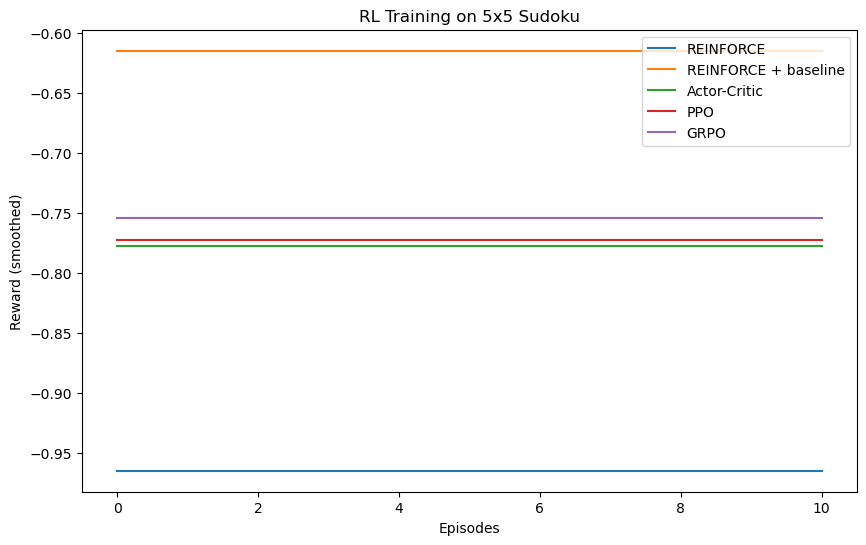

In [35]:
import matplotlib.pyplot as plt

def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(10,6))

plt.plot(smooth(reinforce_rewards), label="REINFORCE")
plt.plot(smooth(rb_rewards), label="REINFORCE + baseline")
plt.plot(smooth(ac_rewards), label="Actor-Critic")
plt.plot(smooth(ppo_rewards), label="PPO")
plt.plot(smooth(grpo_rewards), label="GRPO")

plt.title("RL Training on 5x5 Sudoku")
plt.xlabel("Episodes")
plt.ylabel("Reward (smoothed)")
plt.legend()
plt.show()

# Evaluation ...

In [36]:
import numpy as np

def evaluate_policy(env, policy, Q=None, mode="policy", episodes=50):
    results = []
    solved_grids = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            actions = env.available_actions()

            # --------------------------
            # Q-learning / SARSA / MC
            # --------------------------
            if mode in ["q", "sarsa", "mc"]:
                s = tuple(state.flatten())
                action = max(actions, key=lambda a: Q[(s, a)])

            # --------------------------
            # REINFORCE / PPO / Actor-Critic
            # --------------------------
            else:
                s = encode_state(state)
                probs = policy(s)
                action_idx = torch.argmax(probs).item()
                action = ACTIONS[action_idx]

            state, reward, done = env.step(action)
            total_reward += reward

            if done:
                break

        results.append(total_reward)
        solved_grids.append(state.copy())

    return results, solved_grids

In [37]:
reinforce_eval, reinforce_grids = evaluate_policy(env, policy_reinforce, mode="policy")
ac_eval, ac_grids = evaluate_policy(env, policy_ac, mode="policy")
ppo_eval, ppo_grids = evaluate_policy(env, policy_ppo, mode="policy")
grpo_eval, grpo_grids = evaluate_policy(env, policy_grpo, mode="policy")

KeyboardInterrupt: 

In [ ]:
def summary(name, rewards):
    print("\n======================")
    print(name)
    print("Avg Reward:", np.mean(rewards))
    print("Max Reward:", np.max(rewards))
    print("Min Reward:", np.min(rewards))
    print("Success rate (reward > threshold):",
          np.mean(np.array(rewards) > 5))
    print("======================")

summary("REINFORCE", reinforce_eval)
summary("Actor-Critic", ac_eval)
summary("PPO", ppo_eval)
summary("GRPO", grpo_eval)

In [ ]:
def print_grid(grid):
    print(np.array(grid))

print("=== Best reinforce solution ===")
print_grid(q_grids[np.argmax(reinforce_eval)])

print("\n=== Best PPO solution ===")
print_grid(ppo_grids[np.argmax(ppo_eval)])

print("\n=== Best Actor-Critic solution ===")
print_grid(ac_grids[np.argmax(ac_eval)])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(ppo_eval, label="PPO")
plt.plot(ac_eval, label="Actor-Critic")
plt.plot(reinforce_eval, label="REINFORCE")

plt.title("Evaluation Performance (Post-training)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.show()